<a href="https://colab.research.google.com/github/rishyg20/Alpha-Research---Assignment-2/blob/main/Alpha_Research_Assignment2_Pushkal_Rishabh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Alpha Research — Assignment 2
### Team: Pushkal & Rishabh

In [1]:
try:
    from fredapi import Fred
except:
    !pip install fredapi
    from fredapi import Fred
try:
    import contexttimer
except:
    !pip install contexttimer
    import contexttimer

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf
from datetime import datetime, timedelta
import time
import os
import requests

## Section 2: S&P 500 Constituents

In [2]:
start = time.time()
header = {'User-Agent': 'Chrome'}
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
response = requests.get(url, headers= header)
tables = pd.read_html(response.text)
sp500 = tables[0]

today = datetime.today().strftime("%Y-%m-%d")
sp500['download_date'] = today
print(sp500.shape)
print(sp500.head())
display(sp500)
end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")

(503, 9)
  Symbol             Security             GICS Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                GICS Sub-Industry    Headquarters Location  Date added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisconsin  2017-07-26   
2           Health Care Equipment  North Chicago, Illinois  1957-03-04   
3                   Biotechnology  North Chicago, Illinois  2012-12-31   
4  IT Consulting & Other Services          Dublin, Ireland  2011-07-06   

       CIK      Founded download_date  
0    66740         1902    2026-05-20  
1    91142         1916    2026-05-20  
2     1800         1888    2026-05-20  
3  1551152  2013 (1888)    2026-05-20  
4  

/tmp/ipykernel_21099/669635921.py:5: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded,download_date
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902,2026-05-20
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916,2026-05-20
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888,2026-05-20
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888),2026-05-20
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989,2026-05-20
...,...,...,...,...,...,...,...,...,...
498,XYL,Xylem Inc.,Industrials,Industrial Machinery & Supplies & Components,"White Plains, New York",2011-11-01,1524472,2011,2026-05-20
499,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",1997-10-06,1041061,1997,2026-05-20
500,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",2019-12-23,877212,1969,2026-05-20
501,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",2001-08-07,1136869,1927,2026-05-20


Time taken: 0.28 seconds


In [3]:
start = time.time()

stock_list = sp500['Symbol'].tolist()
end_date = datetime.today().strftime("%Y-%m-%d")
start_date = "2020-01-01"
#downloading Adj Stock price of SP500 constituents
prices = yf.download(stock_list, start = start_date, end = end_date, auto_adjust = True)
display(prices)
print(prices.shape)


end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")
#yfinance drops Adj Close when auto_adjust=True — adjusted prices are stored under Close instead.

[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2020-01-01 -> 2026-05-20)')


Price      Adj Close             Close                                      \
Ticker          BF.B BRK.B           A        AAPL        ABBV        ABNB   
Date                                                                         
2020-01-02       NaN   NaN   82.210434   72.333870   68.696251         NaN   
2020-01-03       NaN   NaN   80.890495   71.630646   68.044189         NaN   
2020-01-06       NaN   NaN   81.129623   72.201431   68.581177         NaN   
2020-01-07       NaN   NaN   81.378311   71.861839   68.189957         NaN   
2020-01-08       NaN   NaN   82.181755   73.017830   68.673233         NaN   
...              ...   ...         ...         ...         ...         ...   
2026-05-13       NaN   NaN  112.739998  298.869995  208.500000  132.970001   
2026-05-14       NaN   NaN  113.260002  298.209991  210.770004  133.669998   
2026-05-15       NaN   NaN  111.699997  300.230011  210.389999  132.850006   
2026-05-18       NaN   NaN  112.110001  297.839996  209.410004  134.300003   
2026-05-19       NaN   NaN  110.570000  298.970001  213.759995  131.160004   

Price                                                     ...   Volume  \
Ticker            ABT       ACGL         ACN        ADBE  ...       WY   
Date                                                      ...            
2020-01-02  77.328728  41.268997  190.896179  334.429993  ...  4973500   
2020-01-03  76.386032  41.221451  190.578217  331.809998  ...  3111000   
2020-01-06  76.786224  41.383106  189.333694  333.709991  ...  2178600   
2020-01-07  76.359344  41.040779  185.246048  333.390015  ...  2426200   
2020-01-08  76.670616  40.631893  185.609375  337.869995  ...  2299800   
...               ...        ...         ...         ...  ...      ...   
2026-05-13  83.830002  93.320000  159.639999  236.070007  ...  7638700   
2026-05-14  84.900002  93.459999  163.990005  237.009995  ...  4360100   
2026-05-15  84.470001  93.980003  168.820007  247.600006  ...  6414400   
2026-05-18  87.910004  95.870003  177.550003  255.639999  ...  4714800   
2026-05-19  88.820000  96.389999  176.800003  254.990005  ...  5812800   

Price                                                                        \
Ticker         WYNN      XEL       XOM      XYL       XYZ      YUM      ZBH   
Date                                                                          
2020-01-02  3006500  2915400  12456400   869500   5264700  1369900  1083972   
2020-01-03  1760500  2422500  17386900   795100   5087100  1145500   992405   
2020-01-06  1357900  2217100  20081900   817300   5905200  1454100   972423   
2020-01-07  1722100  1861100  17387700   662200  10368200  1388600   934519   
2020-01-08  1176200  4828900  15137700  1083200  11899200  1521500   936064   
...             ...      ...       ...      ...       ...      ...      ...   
2026-05-13  1555100  3867900  15772800  1987300   6467700  1701000  2239200   
2026-05-14  2040700  4269500  11331500  1961000   5270800  1507100  2170800   
2026-05-15  1028100  4702200  27882400  2303900   5109300  2156600  2578900   
2026-05-18  1341000  4971700  20065200  2342400   4806000  1418300  2303200   
2026-05-19  1002200  3642800  20715600  1794300   5723800  1625300  2918400   

Price                          
Ticker         ZBRA       ZTS  
Date                           
2020-01-02   387800   1576700  
2020-01-03   305300   1274000  
2020-01-06   322600   2334100  
2020-01-07   236300   1224500  
2020-01-08   689600   1766700  
...             ...       ...  
2026-05-13  1392500  13085600  
2026-05-14  1264600   8714800  
2026-05-15  1224600   8952000  
2026-05-18  1067700   8848300  
2026-05-19  1096000   7295300  

[1603 rows x 2517 columns]

(1603, 2517)
Time taken: 103.35 seconds


In [4]:
start = time.time()
adj_close = prices['Close']
print(adj_close.shape)
print(adj_close.head())
adj_close.to_csv("DATA_PATH" + f"prices_close{today}.csv")
print(f"File saved for {adj_close.shape[1]} stocks, {adj_close.shape[0]} trading days")

end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")

(1603, 503)
Ticker              A       AAPL       ABBV  ABNB        ABT       ACGL  \
Date                                                                      
2020-01-02  82.210434  72.333870  68.696251   NaN  77.328728  41.268997   
2020-01-03  80.890495  71.630646  68.044189   NaN  76.386032  41.221451   
2020-01-06  81.129623  72.201431  68.581177   NaN  76.786224  41.383106   
2020-01-07  81.378311  71.861839  68.189957   NaN  76.359344  41.040779   
2020-01-08  82.181755  73.017830  68.673233   NaN  76.670616  40.631893   

Ticker             ACN        ADBE         ADI        ADM  ...         WY  \
Date                                                       ...              
2020-01-02  190.896179  334.429993  107.791649  38.509468  ...  23.394991   
2020-01-03  190.578217  331.809998  105.894150  38.434299  ...  23.434795   
2020-01-06  189.333694  333.709991  104.650002  38.133640  ...  23.387030   
2020-01-07  185.246048  333.390015  107.030869  37.674294  ...  23.235785   


In [5]:
#converting stock prices to monthly returns
start = time.time()
monthly_prices = adj_close.resample('ME').last()
monthly_returns = monthly_prices.pct_change()
print(monthly_returns.head())
print(monthly_returns.shape)
end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")

Ticker             A      AAPL      ABBV  ABNB       ABT      ACGL       ACN  \
Date                                                                           
2020-01-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2020-02-29 -0.066497 -0.114701  0.057887   NaN -0.116021 -0.084466 -0.119975   
2020-03-31 -0.068350 -0.069762 -0.111072   NaN  0.024407 -0.296067 -0.095963   
2020-04-30  0.070372  0.155374  0.094972   NaN  0.171940 -0.155657  0.139444   
2020-05-31  0.149752  0.085094  0.127373   NaN  0.030731  0.174365  0.088720   

Ticker          ADBE       ADI       ADM  ...        WY      WYNN       XEL  \
Date                                      ...                                 
2020-01-31       NaN       NaN       NaN  ...       NaN       NaN       NaN   
2020-02-29 -0.017144 -0.000984 -0.152230  ... -0.102591 -0.136921 -0.099292   
2020-03-31 -0.077886 -0.177900 -0.065604  ... -0.339655 -0.442582 -0.026146   
2020-04-30  0.111237  0.222532  0.055713  ..

/tmp/ipykernel_21099/490572405.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_returns = monthly_prices.pct_change()


In [6]:
#Feature creation - Momentum & Volatility

start = time.time()

momentum = monthly_returns.shift(1).rolling(window=11).sum()
print(momentum.shape)
print(momentum.head(15))
#Feature 2 : Volatility
volatility = monthly_returns.rolling(window = 12).std()
print(volatility.shape)

vix = yf.download("^VIX", start = start_date, end = end_date, auto_adjust = True)['Close']
vix_m = vix.resample("ME").last()
print(vix_m.shape)
end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")

(77, 503)
Ticker             A      AAPL      ABBV  ABNB       ABT      ACGL       ACN  \
Date                                                                           
2020-01-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2020-02-29       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2020-03-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2020-04-30       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2020-05-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2020-06-30       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2020-07-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2020-08-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2020-09-30       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2020-10-31       NaN       NaN       NaN   NaN       NaN       NaN       NaN   
2020-11-30       NaN       NaN

[*********************100%***********************]  1 of 1 completed

(77, 1)
Time taken: 0.39 seconds


In [7]:
# PIT FRED Data by combing through old releases from ALFRED

from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay

timer = contexttimer.timer()
us_business_day = CustomBusinessDay(calendar=USFederalHolidayCalendar())

fred = Fred(api_key = 'ac02c5e5db97deb2a98467f66618c44d')

SERIES = {
    'DGS3MO'      : '3 Month Treasury Yield',
    'T10Y2Y'      : 'Yield Curve 10yr-2yr',
    'DTWEXBGS'    : 'Trade Weighted Dollar Index',
    'DCOILWTICO'  : 'WTI Crude Oil Price',
    'BAMLH0A0HYM2': 'Credit Spread',
    'UNRATE'      : 'Unemployment Rate',
    'CPIAUCSL'    : 'Inflation CPI',
    'GDPC1'       : 'Real GDP',
    'M2SL'        : 'M2 Money Supply',
    'PCECC96'     : 'Real Personal Consumption',
}

START_DATE = '2020-01-01'
# START_DATE = start_date
est_today = '2026-05-19'

@timer
def releases():
    data = []
    for s in SERIES:
        print(f"Downloading releases for series {s}")
        realtime_start = (pd.to_datetime(START_DATE) - pd.DateOffset(months=12)).strftime('%Y-%m-%d')
        r = fred.get_series_all_releases(s, realtime_start=START_DATE, realtime_end=est_today)
        r = r[r['value'].notna()]
        r['id'] = s
        data.append(r)
    df = pd.concat(data).set_index('id')
    df.date = pd.to_datetime(df.date)
    df.realtime_start = pd.to_datetime(df.realtime_start)
    return df

@timer
def point_in_time(releases_data, end_date = est_today):
    df = pd.DataFrame(index=pd.date_range(START_DATE, end_date, freq=us_business_day))
    df.index.name = 'target_date'
    for s in SERIES:
        print(f"Processing series {s}")
        r = releases_data.loc[s].copy().reset_index()
        r = r.sort_values(['realtime_start', 'date'])

        # only need latest date value published
        # - if the date is pulished for the first time only need it
        # - if only revisions are published only need the latest date value revision
        r = r.drop_duplicates(subset=['realtime_start'], keep='last')

        # carry forward to use the latest data value
        merged = pd.merge_asof(
            pd.DataFrame({'target_date': df.index}),
            r[['realtime_start', 'value', 'date']],
            left_on='target_date',
            right_on='realtime_start',
            direction='backward'
        )
        df[s] = merged['value'].values
        df[f'{s}_pub_date'] = merged['realtime_start'].values
        df[f'{s}_ref_date'] = merged['date'].values
    return df

fred_releases = releases()
fred_pit = point_in_time(releases_data=fred_releases)
fred_pit = fred_pit[list(SERIES.keys())]

#Resampling to monthly

fred_monthly = fred_pit.resample("ME").last().ffill()

print(f"\nFRED data shape: {fred_monthly.shape}")
display(fred_monthly.head(10))
print(fred_monthly.isnull().sum())
fred_monthly= fred_monthly.drop(columns = ['BAMLH0A0HYM2']) #dropping credit spread data since 88 missing values
print(fred_monthly.isnull().sum())
print(f"\nFRED data shape: {fred_monthly.shape}")
end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")

function releases execution time: 21.188 
Processing series DGS3MO
Processing series T10Y2Y
Processing series DTWEXBGS
Processing series DCOILWTICO
Processing series BAMLH0A0HYM2
Processing series UNRATE
Processing series CPIAUCSL
Processing series GDPC1
Processing series M2SL
Processing series PCECC96
function point_in_time execution time: 0.250 

FRED data shape: (77, 10)


/tmp/ipykernel_21099/2485165745.py:76: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fred_monthly = fred_pit.resample("ME").last().ffill()


,DGS3MO,T10Y2Y,DTWEXBGS,DCOILWTICO,BAMLH0A0HYM2,UNRATE,CPIAUCSL,GDPC1,M2SL,PCECC96
target_date,,,,,,,,,,
2020-01-31,1.57,0.18,115.6041,53.09,NaN,3.5,258.501,19219.767,15318.3,13411.938
2020-02-29,1.45,0.27,117.0919,51.36,NaN,3.6,258.820,19220.490,15438.7,13410.416
2020-03-31,0.12,0.47,122.7064,19.48,NaN,3.5,259.050,19221.970,15535.9,13413.811
2020-04-30,0.10,0.44,124.5055,12.17,NaN,4.4,257.953,18987.877,15417.8,13153.000
2020-05-31,0.15,0.49,122.6609,34.70,NaN,14.7,255.902,18974.702,17177.0,13180.837
2020-06-30,0.14,0.50,120.9230,40.60,NaN,13.3,255.768,18977.363,18044.1,13178.952
2020-07-31,0.09,0.44,118.5106,41.46,NaN,11.1,257.214,17205.822,18166.8,11796.645
2020-08-31,0.10,0.58,116.3198,42.44,NaN,10.2,258.723,17282.188,18166.6,11819.579
2020-09-30,0.09,0.56,118.2650,40.47,NaN,8.4,259.681,17302.511,18326.9,11860.250


DGS3MO           0
T10Y2Y           0
DTWEXBGS         0
DCOILWTICO       0
BAMLH0A0HYM2    40
UNRATE           0
CPIAUCSL         0
GDPC1            0
M2SL             0
PCECC96          0
dtype: int64
DGS3MO        0
T10Y2Y        0
DTWEXBGS      0
DCOILWTICO    0
UNRATE        0
CPIAUCSL      0
GDPC1         0
M2SL          0
PCECC96       0
dtype: int64

FRED data shape: (77, 9)
Time taken: 43.57 seconds


In [8]:
# DATA QUALITY OBSERVATIONS - FRED Macro Data
# =============================================

# DGS3MO (3M Treasury): 2706 daily obs → resampled to 125 monthly
# T10Y2Y (Yield Curve): 2707 daily obs → resampled to 125 monthly
# DTWEXBGS (Dollar Index): 2706 daily obs → resampled to 125 monthly
# DCOILWTICO (WTI Oil): 2702 daily obs → resampled to 125 monthly

# BAMLH0A0HYM2 (Credit Spread): 88 missing values at start of period
# → Series begins after 2016-01-01, shorter history than other series
# → Will handle with dropna() or ffill() during join

# UNRATE, CPIAUCSL, M2SL: Monthly frequency, 124 obs
# GDPC1, PCECC96: Quarterly frequency, only 41 obs
# → Forward filled to monthly using .ffill()

# OVERALL: 125 rows x 10 columns after resampling
# Matches monthly_returns shape (125 x 503) - ready for joining

In [9]:
# FRED release data changes
fred_releases

print('Changes in FRED series releases from 2026-05-15 to 2026-05-19')
dates = pd.date_range('2026-05-15', '2026-05-19')
g = fred_releases[fred_releases.realtime_start.isin(dates)].groupby(['id', 'date']).count()
display(g[g.value > 1])

print('\n\nChange example:')
display(fred_releases.loc[(fred_releases.index == 'PCECC96') & (fred_releases.date == '2025-07-01')])

Changes in FRED series releases from 2026-05-15 to 2026-05-19


,,realtime_start,value
id,date,,




Change example:


,realtime_start,date,value
id,,,
PCECC96,2025-12-23,2025-07-01,16589.126
PCECC96,2026-01-22,2025-07-01,16585.878


In [10]:
#Section 4b - Fama French
import zipfile
import io

start = time.time()

#url from Kenneth French Data Library
ff_url = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip'

#download and unzip
r = requests.get(ff_url)
z = zipfile.ZipFile(io.BytesIO(r.content))
ff_raw = pd.read_csv(z.open(z.namelist()[0]), skiprows = 3, index_col = 0)

print(ff_raw.head(10))
print(ff_raw.tail(10))
print(ff_raw.index[:5].tolist())

#Keeping monthly values only
def is_valid_month(val):
  try:
    v = int(str(val).strip())
    return 190000 <= v <= 210000
  except:
    return False

ff_monthly = ff_raw[ff_raw.index.map(is_valid_month)].copy()
print(ff_monthly.index[:10].tolist())  # show first 10 index values
print(type(ff_monthly.index[0]))       # show what type they are
ff_monthly.index = pd.to_datetime(ff_monthly.index.astype(str), format = "%Y%m")
ff_monthly.index = ff_monthly.index + pd.offsets.MonthEnd(0)

ff_monthly = ff_monthly.apply(pd.to_numeric, errors = 'coerce')/100

ff_monthly = ff_monthly[start_date:end_date]

print(f"Fama - French shape: {ff_monthly.shape}")
print(f"Columns: {ff_monthly.columns.tolist()}")

display(ff_monthly.head())

end = time.time()



print(f"Time taken: {round(end - start,2)} seconds")



          Mkt-RF       SMB       HML       RMW       CMA        RF
196307     -0.39     -0.48     -0.81      0.64     -1.15      0.27
196308      5.08     -0.80      1.70      0.40     -0.38      0.25
196309     -1.57     -0.43      0.00     -0.78      0.15      0.27
196310      2.54     -1.34     -0.04      2.79     -2.25      0.29
196311     -0.86     -0.85      1.73     -0.43      2.27      0.27
196312      1.83     -1.89     -0.21      0.12     -0.25      0.29
196401      2.27      0.10      1.63      0.21      1.48      0.30
196402      1.55      0.33      2.81      0.11      0.81      0.26
196403      1.41      1.41      3.29     -2.03      2.98      0.31
196404      0.11     -1.48     -0.54     -1.32     -1.13      0.29
                                                      Mkt-RF       SMB  \
  2017                                                 21.51     -6.27   
  2018                                                 -6.83     -5.06   
  2019                                   

,Mkt-RF,SMB,HML,RMW,CMA,RF
2020-01-31,-0.0009,-0.0437,-0.0622,-0.0119,-0.0219,0.0013
2020-02-29,-0.0815,0.0008,-0.0382,-0.0143,-0.0253,0.0012
2020-03-31,-0.1335,-0.0818,-0.1383,-0.0161,0.0119,0.0012
2020-04-30,0.1358,0.0257,-0.0134,0.0276,-0.0102,0.0000
2020-05-31,0.0559,0.0192,-0.0500,0.0096,-0.0316,0.0001


Time taken: 0.22 seconds


In [12]:
# Joining the data

start = time.time()

# Stack each wide dataframe into long format
returns_long = monthly_returns.stack().reset_index()
returns_long.columns = ['date', 'ticker', 'return']

momentum_long = momentum.stack().reset_index()
momentum_long.columns = ['date', 'ticker', 'momentum']

volatility_long = volatility.stack().reset_index()
volatility_long.columns = ['date', 'ticker', 'volatility']

# Merge price-based signals
panel = returns_long.merge(momentum_long, on=['date', 'ticker'], how='inner')
panel = panel.merge(volatility_long, on=['date', 'ticker'], how='inner')
print(f"After price signals: {panel.shape}")

# Fix fred_monthly - always reset index cleanly
fred_clean = fred_monthly.copy()
if fred_clean.index.name == 'date' or fred_clean.index.name is not None:
    fred_clean = fred_clean.reset_index()
fred_clean.columns = [c if c != 'index' else 'date' for c in fred_clean.columns]
fred_clean = fred_clean[[c for c in fred_clean.columns if c not in ['level_0', 'level_1']]]

# Fix ff_monthly - same approach
ff_clean = ff_monthly.copy()
if ff_clean.index.name == 'date' or ff_clean.index.name is not None:
    ff_clean = ff_clean.reset_index()
ff_clean.columns = [c if c != 'index' else 'date' for c in ff_clean.columns]
ff_clean = ff_clean[[c for c in ff_clean.columns if c not in ['level_0', 'level_1']]]

print(fred_clean.columns.tolist())
print(ff_clean.columns.tolist())

print("fred_clean columns:", fred_clean.columns.tolist())
print("fred_clean index name:", fred_clean.index.name)
print("fred_clean head:")
print(fred_clean.head(2))

print("panel columns:", panel.columns.tolist())
print("panel index name:", panel.index.name)

fred_clean = fred_monthly.copy().reset_index()
fred_clean.columns = ['date'] + [c for c in fred_clean.columns[1:]]

ff_clean = ff_monthly.copy().reset_index()
ff_clean.columns = ['date'] + [c for c in ff_clean.columns[1:]]

print(fred_clean.columns.tolist())
print(fred_clean.head(2))

# Merge macro data
panel = panel.merge(fred_clean, on='date', how='left')
panel = panel.merge(ff_clean, on='date', how='left')

vix_df = vix_m.reset_index()
vix_df.columns = ['date', 'VIX']
panel = panel.merge(vix_df, on='date', how='left')

print(f"Final panel: {panel.shape}")
display(panel.head())

end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")

After price signals: (32100, 5)
['target_date', 'DGS3MO', 'T10Y2Y', 'DTWEXBGS', 'DCOILWTICO', 'UNRATE', 'CPIAUCSL', 'GDPC1', 'M2SL', 'PCECC96']
['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
fred_clean columns: ['target_date', 'DGS3MO', 'T10Y2Y', 'DTWEXBGS', 'DCOILWTICO', 'UNRATE', 'CPIAUCSL', 'GDPC1', 'M2SL', 'PCECC96']
fred_clean index name: None
fred_clean head:
  target_date  DGS3MO  T10Y2Y  DTWEXBGS  DCOILWTICO  UNRATE  CPIAUCSL  \
0  2020-01-31    1.57    0.18  115.6041       53.09     3.5   258.501   
1  2020-02-29    1.45    0.27  117.0919       51.36     3.6   258.820   

       GDPC1     M2SL    PCECC96  
0  19219.767  15318.3  13411.938  
1  19220.490  15438.7  13410.416  
panel columns: ['date', 'ticker', 'return', 'momentum', 'volatility']
panel index name: None
['date', 'DGS3MO', 'T10Y2Y', 'DTWEXBGS', 'DCOILWTICO', 'UNRATE', 'CPIAUCSL', 'GDPC1', 'M2SL', 'PCECC96']
        date  DGS3MO  T10Y2Y  DTWEXBGS  DCOILWTICO  UNRATE  CPIAUCSL  \
0 2020-01-31    1.57    0.18  115.6041 

,date,ticker,return,momentum,volatility,DGS3MO,T10Y2Y,DTWEXBGS,DCOILWTICO,UNRATE,...,GDPC1,M2SL,PCECC96,Mkt-RF,SMB,HML,RMW,CMA,RF,VIX
0,2021-01-31,A,0.015842,0.399590,0.069877,0.07,1.0,111.8936,52.78,6.7,...,18780.325,19188.3,13004.74,-0.0007,0.0681,0.0322,-0.0365,0.0497,0.0,33.09
1,2021-01-31,AAPL,-0.005501,0.632621,0.116352,0.07,1.0,111.8936,52.78,6.7,...,18780.325,19188.3,13004.74,-0.0007,0.0681,0.0322,-0.0365,0.0497,0.0,33.09
2,2021-01-31,ABBV,-0.032398,0.369043,0.093976,0.07,1.0,111.8936,52.78,6.7,...,18780.325,19188.3,13004.74,-0.0007,0.0681,0.0322,-0.0365,0.0497,0.0,33.09
3,2021-01-31,ABT,0.133327,0.271548,0.080205,0.07,1.0,111.8936,52.78,6.7,...,18780.325,19188.3,13004.74,-0.0007,0.0681,0.0322,-0.0365,0.0497,0.0,33.09
4,2021-01-31,ACGL,-0.129193,-0.101325,0.132488,0.07,1.0,111.8936,52.78,6.7,...,18780.325,19188.3,13004.74,-0.0007,0.0681,0.0322,-0.0365,0.0497,0.0,33.09


Time taken: 0.14 seconds


In [13]:
start = time.time()

print(panel.dtypes)
print(panel.isnull().sum())
panel = panel.dropna(subset = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF'])
print(panel.dtypes)
print(panel.isnull().sum())
print(panel.shape)

#Adding derived macro factors
panel['CPI_change'] = panel.groupby('ticker')['CPIAUCSL'].pct_change()
panel['GDP_growth'] = panel.groupby('ticker')['GDPC1'].pct_change()
panel['Oil_change'] = panel.groupby('ticker')['DCOILWTICO'].pct_change()

panel = panel.dropna(subset = ['CPI_change', 'GDP_growth', 'Oil_change'])
print(panel.isnull().sum())
print(panel.shape)

end = time.time()
print(f"Time taken: {round(end - start,2)} seconds")




date          datetime64[ns]
ticker                object
return               float64
momentum             float64
volatility           float64
DGS3MO               float64
T10Y2Y               float64
DTWEXBGS             float64
DCOILWTICO           float64
UNRATE               float64
CPIAUCSL             float64
GDPC1                float64
M2SL                 float64
PCECC96              float64
Mkt-RF               float64
SMB                  float64
HML                  float64
RMW                  float64
CMA                  float64
RF                   float64
VIX                  float64
dtype: object
date             0
ticker           0
return           0
momentum         0
volatility       0
DGS3MO           0
T10Y2Y           0
DTWEXBGS         0
DCOILWTICO       0
UNRATE           0
CPIAUCSL         0
GDPC1            0
M2SL             0
PCECC96          0
Mkt-RF        1000
SMB           1000
HML           1000
RMW           1000
CMA           1000
RF            10

In [14]:
#Forward return - predictand

if 'forward_return' not in panel.columns:
    panel['forward_return'] = panel.groupby('ticker')['return'].shift(-1)
    panel = panel.dropna(subset=['forward_return'])
print(panel.shape)


# Define X and Y
y = panel['forward_return']

X_cols = [
    'momentum',
    'VIX',
    'volatility',
    'DGS3MO',
    'T10Y2Y',
    'Mkt-RF',
    'SMB',
    'HML',
    'RMW',
    'CMA',
    'CPI_change',
    'GDP_growth',
    'Oil_change'
]

X = panel[X_cols]

X = sm.add_constant(X)

print(X.shape)
print(y.shape)

model = sm.OLS(y, X)

results = model.fit()

print(results.summary())

(30100, 25)
(30100, 14)
(30100,)
                            OLS Regression Results                            
Dep. Variable:         forward_return   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     157.8
Date:                Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                        19:29:53   Log-Likelihood:                 29834.
No. Observations:               30100   AIC:                        -5.964e+04
Df Residuals:                   30086   BIC:                        -5.952e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.11

R-squared: 0.0638
Adjusted R-squared: 0.0634
F-statistic p-value: 0.000000
Number of observations: 30100


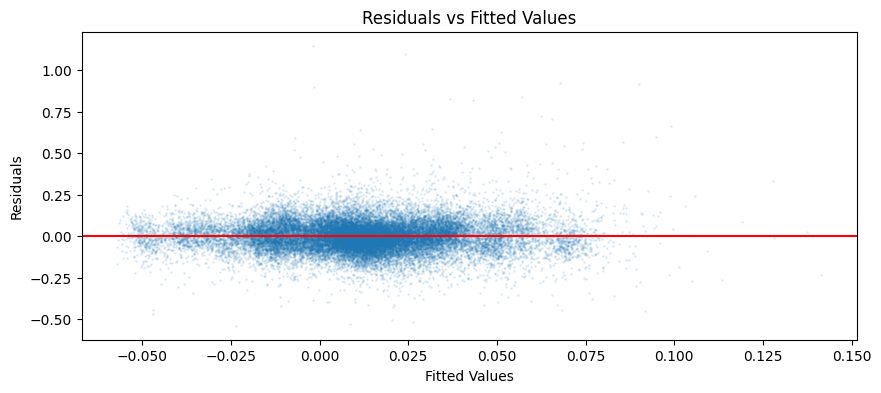

In [15]:
# Key results summary
print(f"R-squared: {results.rsquared:.4f}")
print(f"Adjusted R-squared: {results.rsquared_adj:.4f}")
print(f"F-statistic p-value: {results.f_pvalue:.6f}")
print(f"Number of observations: {results.nobs:.0f}")

# Plot actual vs predicted
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.scatter(results.fittedvalues, results.resid, alpha=0.1, s=1)
plt.axhline(0, color='red')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()